# Weeks 11 Exercises
### Author: Nicholas Stirling
### Date: 11/23/25
#### Description: This notebook completes assignment activities for Week 11 of DSC550-T301. Loading the MNIST dataset, diplaying the first five images, building and training a CNN classifier on the training set, report the accuracy, display a confusion matric and summarizing the results.

In [1]:
import tensorflow as tf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print(tf.__version__)

2.19.1


In [2]:
# Load the MNIST data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and reshape the data prior to processing
input_shape = (28, 28, 1)

x_train=x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_train=x_train / 255.0
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
x_test=x_test/255.0

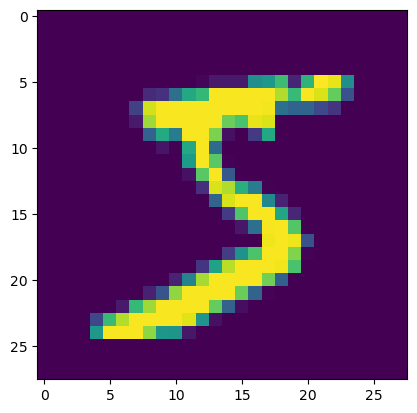

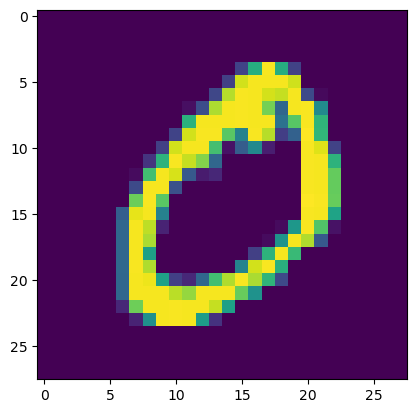

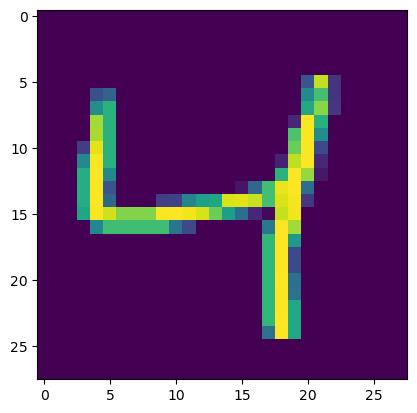

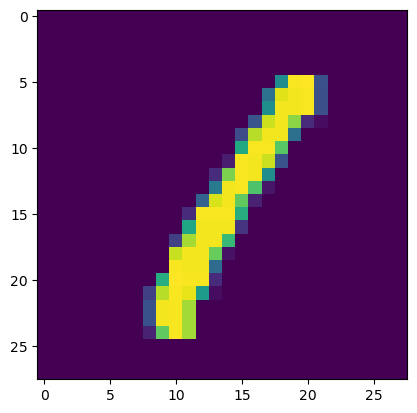

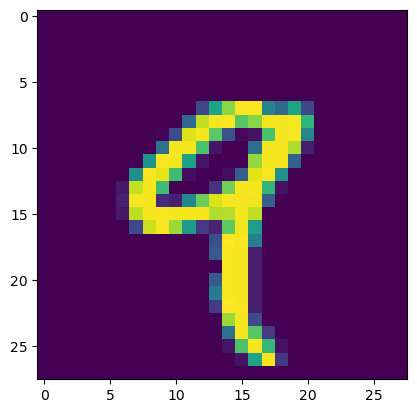

In [3]:
# Visualize the first 5 images of the training set
plt.imshow(x_train[0][:,:,0])
plt.show()
plt.imshow(x_train[1][:,:,0])
plt.show()
plt.imshow(x_train[2][:,:,0])
plt.show()
plt.imshow(x_train[3][:,:,0])
plt.show()
plt.imshow(x_train[4][:,:,0])

In [4]:
print(y_train[0:5])

[5 0 4 1 9]


In [5]:
# Label one hot encoding
y_train = tf.one_hot(y_train.astype(np.int32), depth=10)
y_test = tf.one_hot(y_test.astype(np.int32), depth=10)

In [6]:
# Define model batches, classes, and epochs
batch_size = 64
num_classes = 10
epochs = 5

# Build the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu', input_shape=input_shape),
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(strides=(2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.RMSprop(epsilon=1e-08), loss='categorical_crossentropy', metrics=['acc'])

C:\Users\Laurie\anaconda3\envs\Work\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Callback for ifaccuracy reaches 99.5% we stop training
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('acc')>0.995):
      print("\nReached 99.5% accuracy so cancelling training!")
      self.model.stop_training = True

callbacks = myCallback()

In [8]:
# Testing the model on a validation set to prevent overfitting
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_split=0.1,
                    callbacks=[callbacks])

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - acc: 0.9306 - loss: 0.2255 - val_acc: 0.9883 - val_loss: 0.0398
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - acc: 0.9786 - loss: 0.0760 - val_acc: 0.9913 - val_loss: 0.0304
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - acc: 0.9836 - loss: 0.0579 - val_acc: 0.9912 - val_loss: 0.0299
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - acc: 0.9860 - loss: 0.0499 - val_acc: 0.9923 - val_loss: 0.0289
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - acc: 0.9871 - loss: 0.0484 - val_acc: 0.9913 - val_loss: 0.0363


In [9]:
# Predict the results and check accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9917 - loss: 0.0271


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Axes: >

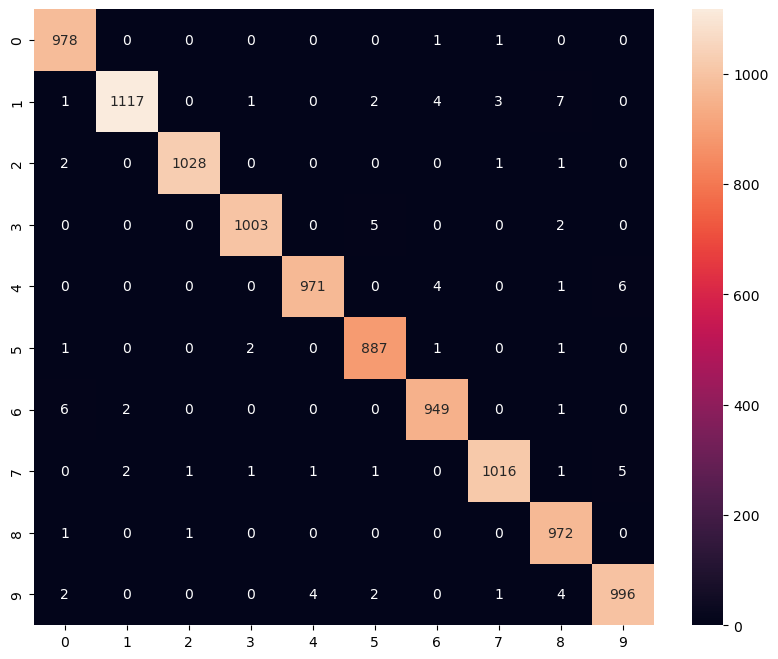

In [12]:
# Compute the confusion matrix using TensorFlow
# Predict the values from the testing dataset
Y_pred = model.predict(x_test)
# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_pred,axis = 1) 
# Convert testing observations to one hot vectors
Y_true = np.argmax(y_test,axis = 1)
# compute the confusion matrix
confusion_mtx = tf.math.confusion_matrix(Y_true, Y_pred_classes) 

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='g')

All 5 Epochs ran as the cutoff accuracy of 99.5% was not reached during the training. The final Accuracy reached when predicting the values of the test set was 99.17%. The confusion matrix shows that there was higher confusions between (0,6), (4,9), (5,3), and (8,1). While several of these can make sense due to shapes like 0 and 6 or 4 and 9, the 8 and 1 is harder to understand based on the standard expected shapes.